In [1]:
import ast
import itertools
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import scipy.stats
import seaborn as sns

from scipy.integrate import quad
from scipy.stats import ttest_1samp, ttest_ind, t as tdist, nct
import statsmodels.formula.api as smf
import statsmodels.api as sm
from typing import List

In [2]:
def get_completion_time(workload_orders, value):
    """
    value: [chef1_list, chef2_list]
      where each list can be either:
      - list of ints (order ids, 1-based), or
      - list of dicts with keys: id, length1, length2
    """

    id_to_len = {o["id"]: (int(o["length1"]), int(o["length2"])) for o in workload_orders}

    chef1_list, chef2_list = value

    # Sum Chef1's own processing times (length1)
    time1 = 0
    for item in chef1_list:
        if isinstance(item, dict):
            time1 += int(item.get("length1"))
        else:
            l1, _ = id_to_len[int(item)]
            time1 += l1

    # Sum Chef2's own processing times (length2)
    time2 = 0
    for item in chef2_list:
        if isinstance(item, dict):
            time2 += int(item.get("length2"))
        else:
            _, l2 = id_to_len[int(item)]
            time2 += l2

    return max(time1, time2)


def parseJSON(filepath):
    """
    Parse workloads JSON file presented as stimuli in Prolific experiment.
    Produces a row per workload with per-algorithm assignments and times,
    plus the algorithm with minimal makespan.
    """
    workload_data = []

    with open(filepath, 'r', encoding='utf-8') as file:
        workloads = json.load(file)['workloads']

    for windex, w in enumerate(workloads):
        winfo = {'index': windex}

        opt_alg = None
        opt_time = np.inf

        # iterate algorithms under "assignments"
        for alg_name, alg_payload in w['assignments'].items():
            key = alg_name.lower()

            chef1 = alg_payload.get('Chef1', [])
            chef2 = alg_payload.get('Chef2', [])

            value = [chef1, chef2]
            result = get_completion_time(w['orders'], value)
            winfo[key] = value
            winfo[f'{key}_time'] = result

            # track best algorithm
            if result < opt_time:
                opt_alg = key
                opt_time = result

        winfo['optimal_alg'] = opt_alg
        winfo['algorithm_time'] = opt_time  

        workload_data.append(winfo)

    return pd.DataFrame(workload_data)

In [6]:
def parseWorkloadData(filepath):
    """
    Parse workload data in JSON file presented as stimuli in Prolific experiment
    """
    workload_data = []
    
    with open(filepath, 'r', encoding='utf-8') as file:
        workloads = json.load(file)['workloads']

        for windex in range( len(workloads) ):
            w = workloads[windex]
            
            winfo = {
                'index': windex
            }

            types = []
            orders = []

            for order in w['orders']:
                o_type = order['type']
                if o_type not in types:
                    types.append(o_type)
                orders.append(o_type)
            
            types.sort()
            winfo['types'] = types
            winfo['order'] = orders
            workload_data.append(winfo)

            chef1_times = [0] * len(types)
            chef2_times = [0] * len(types)

            for i in range(len(types)):
                for order in w['orders']:
                    if order['type'] == types[i]:
                        chef1_times[i] = order['length1']
                        chef2_times[i] = order['length2']
                    if chef1_times[i] != 0 and chef2_times[i] != 0:
                        break

            winfo['chef1_times'] = chef1_times
            winfo['chef2_times'] = chef2_times
                
    df = pd.DataFrame(workload_data)
    return df

In [8]:
def make_combinations(workloads_df):
    def get_completion_time(chef1_assignment: list, chef2_assignment: list, windex: int):
        """
        Return expected completion time of a particular allocation for a workload
        """
        # Compute busy time for Chef 1
        time1 = 0
        for i in chef1_assignment:
            if workloads_df.loc[windex, 'order'][i] == 'A':
                time1 += int(workloads_df.loc[windex, 'chef1_times'][0])
            else:
                time1 += int(workloads_df.loc[windex, 'chef1_times'][1])
                
        # Compute busy time for Chef 2
        time2 = 0
        for i in chef2_assignment:
            if workloads_df.loc[windex, 'order'][i] == 'A':
                time2 += int(workloads_df.loc[windex, 'chef2_times'][0])
            else:
                time2 += int(workloads_df.loc[windex, 'chef2_times'][1])
    
        return(max(time1, time2))
    
    workloads_orders = workloads_df['order'].tolist()
    
    combinations_data = []
    
    for w in range(len(workloads_orders)):  
        combinations_info = {
            'index': w
        }
        
        # start with all jobs assigned to chef 1
        min_chef1_assignment = None
        min_chef2_assignment = None
        worst_assignment = None
        min_completion_time = np.inf
        max_completion_time = 0
        
        for num in range(0, len(workloads_orders[w]) + 1):
            indices = range(len(workloads_orders[w]))
            for chef1_assignment in itertools.combinations(indices, num):
                chef1_assignment = list(chef1_assignment)
                chef2_assignment = [i for i in indices if i not in chef1_assignment]
            
                completion_time = get_completion_time(chef1_assignment, chef2_assignment, w)
                if completion_time < min_completion_time:
                    min_completion_time = completion_time
                    min_chef1_assignment = chef1_assignment
                    min_chef2_assignment = chef2_assignment
                if completion_time > max_completion_time:
                    max_completion_time = completion_time
                    if (chef1_assignment): worst_assignment = 1
                    else: worst_assignment = 2
    
        combinations_info['chef1_assignment'] = [index + 1 for index in min_chef1_assignment]
        combinations_info['chef2_assignment'] = [index + 1 for index in min_chef2_assignment]
        combinations_info['optimal_time'] = min_completion_time
        combinations_info['worst_time'] = max_completion_time
    
        combinations_data.append(combinations_info)
    return pd.DataFrame(combinations_data)

In [9]:
def completion_time_from_ids(order_types, types, chef1_ids, chef2_ids, chef1_times, chef2_times):
    t2i = {t:i for i,t in enumerate(types)}
    t1 = 0
    for job_id in chef1_ids:              
        jtype = order_types[job_id - 1]
        idx = t2i[jtype]
        t1 += int(chef1_times[idx])
    t2 = 0
    for job_id in chef2_ids:
        jtype = order_types[job_id - 1]
        idx = t2i[jtype]
        t2 += int(chef2_times[idx])
    return max(t1, t2)

In [10]:
def make_heuristics(workloads_df):
    workloads_orders = workloads_df['order'].tolist()
    workloads_types  = workloads_df['types'].tolist()
    chef1_times_all  = workloads_df['chef1_times'].tolist()
    chef2_times_all  = workloads_df['chef2_times'].tolist()
    
    rows = []
    for w in range(len(workloads_orders)):
        order_types = workloads_orders[w]
        types       = workloads_types[w]
        c1_times    = chef1_times_all[w]
        c2_times    = chef2_times_all[w]
        n_jobs      = len(order_types)
    
        row = {"index": w}
    
        # ---------- Random (deterministic assignment) ----------
        rng = random.Random(w)   # seed by workload index
        rand_c1, rand_c2 = [], []
        for job_id in range(1, n_jobs+1):
            (rand_c1 if rng.randint(0,1)==0 else rand_c2).append(job_id)
        row["random"] = [rand_c1, rand_c2]
        row["random_time"] = completion_time_from_ids(order_types, types, rand_c1, rand_c2, c1_times, c2_times)
    
        num_random = 200
        rand_times = []
        for _ in range(num_random):
            rrng = random.Random(w*10 + _)   # different seed per sample
            r1, r2 = [], []
            for job_id in range(1, n_jobs+1):
                (r1 if rrng.randint(0,1)==0 else r2).append(job_id)
            rand_times.append(completion_time_from_ids(order_types, types, r1, r2, c1_times, c2_times))
        row["random_mean_time"] = float(np.mean(rand_times))
        row["random_err"]       = float(scipy.stats.sem(rand_times))
    
        # ---------- Fastest Recipe (types) ----------
        types_c1, types_c2 = [], []
        t2i = {t:i for i,t in enumerate(types)}
        # decide who is globally faster per type
        for job_id in range(1, n_jobs+1):
            jtype = order_types[job_id-1]
            idx   = t2i[jtype]
            if int(c1_times[idx]) <= int(c2_times[idx]):
                types_c1.append(job_id)
            else:
                types_c2.append(job_id)
        row["types"] = [types_c1, types_c2]
        row["types_time"] = completion_time_from_ids(order_types, types, types_c1, types_c2, c1_times, c2_times)
    
        # ---------- Round Robin ----------
        rr_c1 = [job_id for job_id in range(1, n_jobs+1) if job_id % 2 == 1]
        rr_c2 = [job_id for job_id in range(1, n_jobs+1) if job_id % 2 == 0]
        row["rr"] = [rr_c1, rr_c2]
        row["rr_time"] = completion_time_from_ids(order_types, types, rr_c1, rr_c2, c1_times, c2_times)
    
        # ---------- Equal Distribution by Type ----------
        equal_c1, equal_c2 = [], []
        seen_by_type = {t:0 for t in types}
        for job_id in range(1, n_jobs+1):
            jtype = order_types[job_id-1]
            seen_by_type[jtype] += 1
            if seen_by_type[jtype] % 2 == 1:
                equal_c1.append(job_id)
            else:
                equal_c2.append(job_id)
        row["equal"] = [equal_c1, equal_c2]
        row["equal_time"] = completion_time_from_ids(order_types, types, equal_c1, equal_c2, c1_times, c2_times)
    
        rows.append(row)
    return pd.DataFrame(rows)

In [3]:
def add_labels(x, y, ax):
    """Add value labels to bar plots"""
    for i, val in enumerate(y):
        ax.text(i, val * 1.05, f"{val:.1f}", ha='center')
        
def plot_subjects(workloads_df, filtered_df, heuristics_df, combinations_df):
    plt.figure(figsize=(12,6))
    
    xlabels = workloads_df['index'].values.tolist()
    subject_times = [filtered_df[f'w{i}_completion_time'].mean() for i in xlabels]
    alg_times = heuristics_df['algorithm_time'].tolist()
    optimal_times = combinations_df['optimal_time'].tolist()
    worst_times = combinations_df['worst_time'].tolist()
    
    x = np.arange(0, len(xlabels)) 
    width = 0.3
    
    subject_sems = [filtered_df[f'w{i}_completion_time'].sem() for i in xlabels]
    
    fig, ax = plt.subplots()
    ax.bar(x - 3*width/4, subject_times, width/2, label='Subjects', color='orange', yerr=subject_sems)
    ax.bar(x - width/4, alg_times, width/2, label='Optimal Heuristic', color='blue')
    ax.bar(x + width/4, optimal_times, width/2, label='Optimal Combination', color='green')
    
    plt.xlabel('Workload')
    plt.ylabel('Expected Completion Time')
    plt.title('Offline: Average Subject vs. Optimal and Worst Allocations')
    plt.legend(title='Allocation by...', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [4]:
def make_comparison_plots(workloads_df, methods_df, heuristics_df, combinations_df, filtered_df):
    xlabels = workloads_df['index'].values.tolist()
    random_times = methods_df['random_time'].tolist()
    types_times = methods_df['types_time'].tolist()
    rr_times = methods_df['rr_time'].tolist()
    equal_times = methods_df['equal_time'].tolist()
    subject_times = [filtered_df[f'w{i}_completion_time'].mean() for i in xlabels]
    alg_times = heuristics_df['algorithm_time'].tolist()
    optimal_times = combinations_df['optimal_time'].tolist()
    worst_times = combinations_df['worst_time'].tolist()
    greedy_times = heuristics_df['greedy_time'].tolist()
    minmin_times = heuristics_df['minmin_time'].tolist()
    maxmin_times = heuristics_df['maxmin_time'].tolist()
    
    # --- 1. Optimal / Worst comparison ---
    xlabels1 = ['Subjects', 'Best Heuristic', 'Optimal', 'Worst']
    avg_times1 = [np.mean(subject_times), np.mean(alg_times), np.mean(optimal_times), np.mean(worst_times)]
    err_bars1 = [scipy.stats.sem(subject_times), scipy.stats.sem(alg_times),
                 scipy.stats.sem(optimal_times), scipy.stats.sem(worst_times)]
    colors1 = ['orange', 'blue', 'green', 'red']

    # --- 2. Systems algorithms ---
    xlabels2 = ['Subjects', 'Greedy', 'Minmin', 'Maxmin']
    avg_times2 = [np.mean(subject_times), np.mean(greedy_times),
                  np.mean(minmin_times), np.mean(maxmin_times)]
    err_bars2 = [scipy.stats.sem(subject_times), scipy.stats.sem(greedy_times),
                 scipy.stats.sem(minmin_times), scipy.stats.sem(maxmin_times)]
    colors2 = ['orange', 'blue', 'green', 'red']

    # --- 3. Rule-based / simple methods ---
    xlabels3 = ['Subjects', 'Random', 'Fastest Recipe', 'Round Robin', 'Equal Distribution']
    avg_times3 = [np.mean(subject_times), np.mean(random_times), np.mean(types_times),
                  np.mean(rr_times), np.mean(equal_times)]
    err_bars3 = [scipy.stats.sem(subject_times), scipy.stats.sem(random_times),
                 scipy.stats.sem(types_times), scipy.stats.sem(rr_times),
                 scipy.stats.sem(equal_times)]
    colors3 = ['orange', 'blue', 'green', 'red', 'yellow']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    # Panel 1
    axes[0].bar(xlabels1, avg_times1, yerr=err_bars1, color=colors1)
    add_labels(xlabels1, avg_times1, axes[0])
    axes[0].set_title('Offline: Subject vs. Optimal and Worst Allocations')
    axes[0].set_ylabel('Expected Completion Time')
    
    # Panel 2
    axes[1].bar(xlabels2, avg_times2, yerr=err_bars2, color=colors2)
    add_labels(xlabels2, avg_times2, axes[1])
    axes[1].set_title('Average Subject vs. Heuristics')
    
    # Panel 3
    axes[2].bar(xlabels3, avg_times3, yerr=err_bars3, color=colors3)
    add_labels(xlabels3, avg_times3, axes[2])
    axes[2].set_title('Average Subject vs. Methods Across All Workloads')
    
    fig.suptitle('Comparison of Offline Subject Performance Across Allocation Strategies', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

In [11]:
# Load workload definitions and compute algorithmic baselines
workloads_filepath = 'stimuli/workloads.json'
workloads_df    = parseWorkloadData(workloads_filepath)
heuristics_df   = parseJSON(workloads_filepath)
combinations_df = make_combinations(workloads_df)
methods_df      = make_heuristics(workloads_df)

Offline participants: 49
Online participants: 50


<Figure size 1200x600 with 0 Axes>

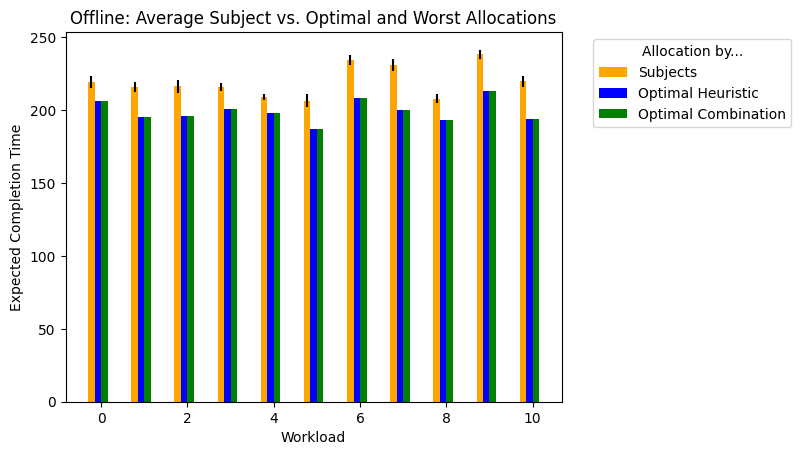

<Figure size 1200x600 with 0 Axes>

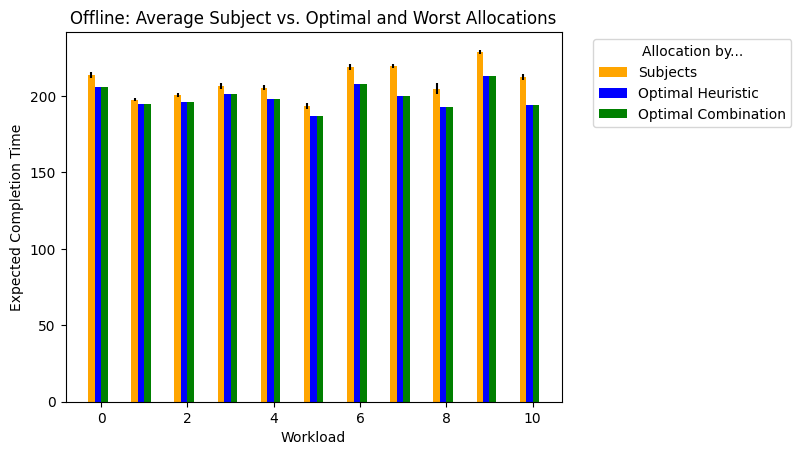

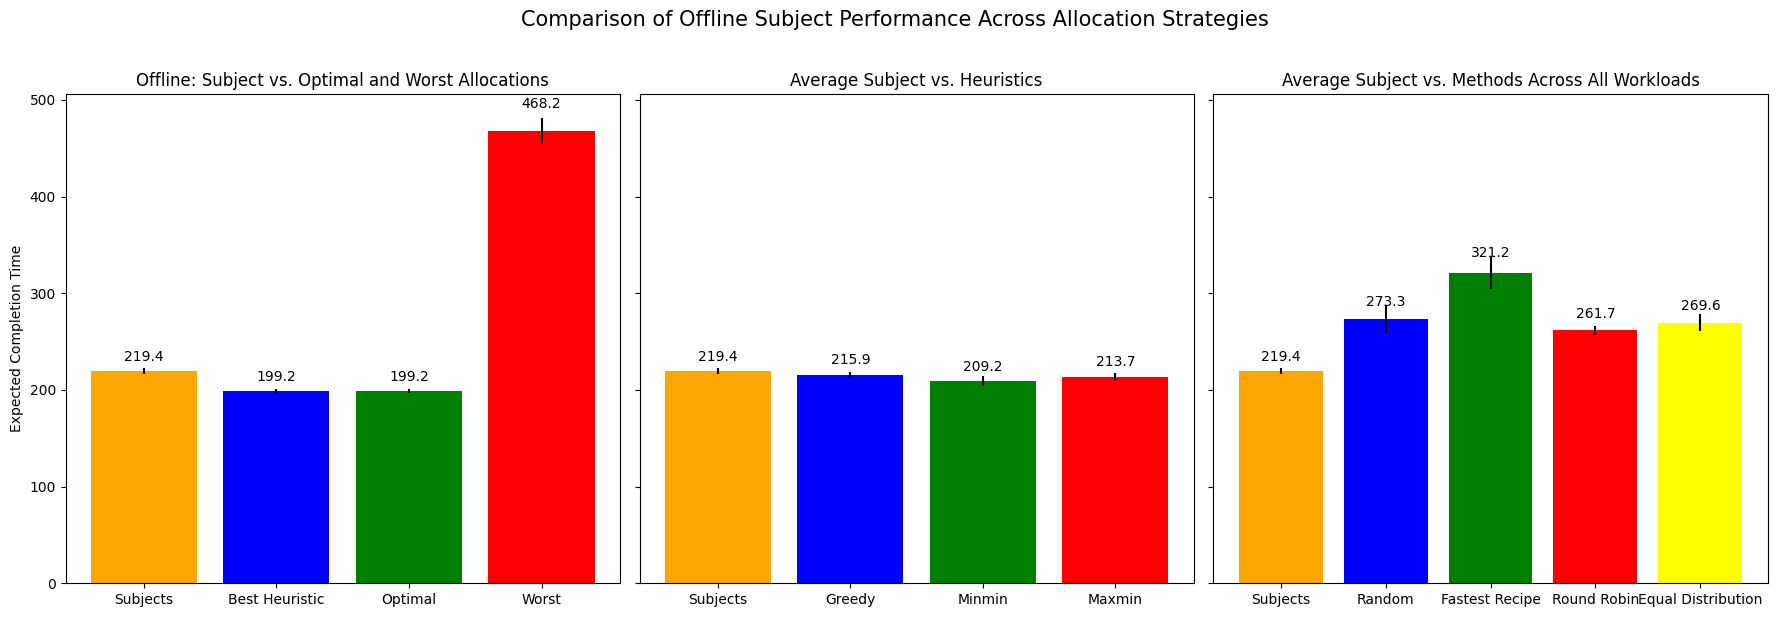

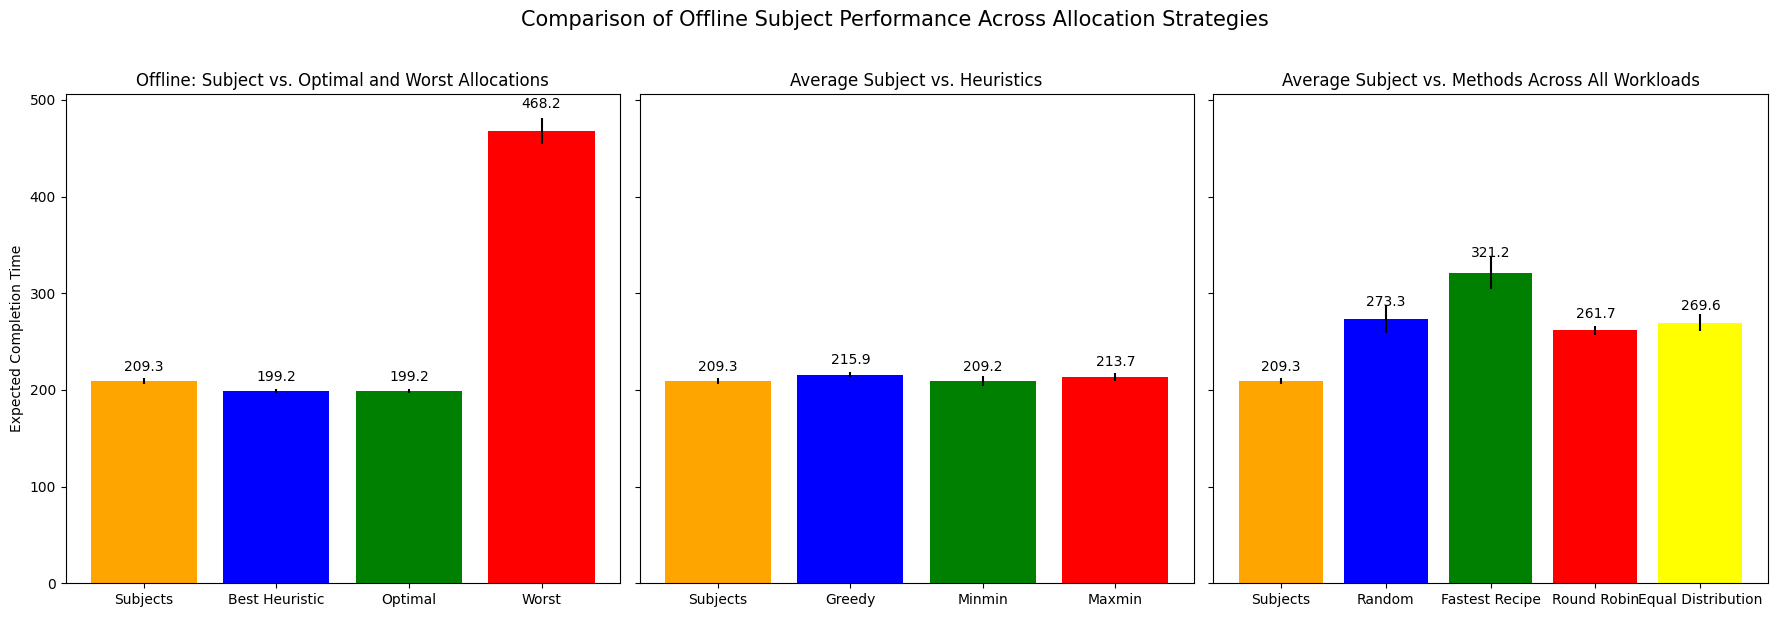

In [13]:
SUBJ_COL = "participant_id"

# Load anonymized participant data
filtered_df_offline = pd.read_csv("public_data/offline_anonymized.csv")
filtered_df_online  = pd.read_csv("public_data/online_anonymized.csv")

chef_cols = [c for c in filtered_df_offline.columns if c.endswith('_chef1') or c.endswith('_chef2')]
for df in [filtered_df_offline, filtered_df_online]:
    for col in chef_cols:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print("Offline participants:", len(filtered_df_offline))
print("Online participants:",  len(filtered_df_online))

plot_subjects(workloads_df, filtered_df_offline, heuristics_df, combinations_df)
plot_subjects(workloads_df, filtered_df_online,  heuristics_df, combinations_df)
make_comparison_plots(workloads_df, methods_df, heuristics_df, combinations_df, filtered_df_offline)
make_comparison_plots(workloads_df, methods_df, heuristics_df, combinations_df, filtered_df_online)

In [14]:
def convert_to_trial_data(filtered_df):
    windex_cols = [c for c in filtered_df.columns if c.startswith("trial") and c.endswith("_windex")]

    SUBJ_COL = "participant_id"
    
    rows = []
    
    for _, row in filtered_df.iterrows():
        subj = row[SUBJ_COL]
        
        for col in windex_cols:
            m = re.match(r"trial(\d+)_windex", col)
            if m is None:
                continue
            trial_num = int(m.group(1))
            
            windex = row[col]
            if pd.isna(windex):
                continue  
            windex = int(windex)
            
            human_col = f"w{windex}_completion_time"
            if human_col not in filtered_df.columns:
                continue
            
            human_time = row[human_col]
            
            rows.append({
                SUBJ_COL: subj,
                "trial": trial_num,
                "windex": windex,
                "human_time": human_time
            })
    
    trial_df = pd.DataFrame(rows)
    
    heur_cols = ["random_mean_time", "types_time", "rr_time", "equal_time"]

    trial_df = trial_df.merge(
        methods_df[["index"] + heur_cols],
        left_on="windex",
        right_on="index",
        how="left"
    )
    
    # best heuristic per trial
    trial_df["best_heur_time"] = trial_df[heur_cols].min(axis=1)
    trial_df["diff_best"] = trial_df["human_time"] - trial_df["best_heur_time"]
    return trial_df

In [15]:
# PRIMARY HYPOTHESIS (PREREG)
# H1: Human allocations are more efficient than the best simple heuristic

trial_df_offline = convert_to_trial_data(filtered_df_offline)

subj_diff_offline = (
    trial_df_offline
    .groupby(SUBJ_COL)["diff_best"]
    .mean()
    .reset_index(name="mean_diff")
)

t_stat, p_val = ttest_1samp(
    subj_diff_offline["mean_diff"],
    popmean=0,
    alternative="less"
)
print("H1: Are people significantly better than basic heuristics?")
print(f"[Offline] t = {t_stat:.3f}, p = {p_val:.4g}, M = {subj_diff_offline['mean_diff'].mean():.2f}")

trial_df_online = convert_to_trial_data(filtered_df_online)

subj_diff_online = (
    trial_df_online
    .groupby(SUBJ_COL)["diff_best"]
    .mean()
    .reset_index(name="mean_diff")
)

t_stat, p_val = ttest_1samp(
    subj_diff_online["mean_diff"],
    popmean=0,
    alternative="less"
)
print(f"[Online]  t = {t_stat:.3f}, p = {p_val:.4g}, M = {subj_diff_online['mean_diff'].mean():.2f}")

H1: Are people significantly better than basic heuristics?
[Offline] t = -15.950, p = 4.066e-21, M = -28.02
[Online]  t = -47.058, p = 9.466e-43, M = -38.13


In [16]:
# H2: Online scheduling outperforms offline (mixed linear model)

trial_df_offline["condition"] = "offline"
trial_df_online["condition"]  = "online"
trial_df = pd.concat([trial_df_offline, trial_df_online], ignore_index=True)

trial_df["condition"] = trial_df["condition"].astype("category")
trial_df["condition"] = trial_df["condition"].cat.reorder_categories(
    ["offline", "online"], ordered=True
)

model = smf.mixedlm(
    "diff_best ~ condition",
    trial_df,
    groups=trial_df[SUBJ_COL],              # subject random intercept
    vc_formula={"w": "0 + C(windex)"}       # workload random intercept
)

res = model.fit(reml=False)
print("H2")
print(res.summary())

H2
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    diff_best 
No. Observations:     1089       Method:                ML        
No. Groups:           50         Scale:                 398.9364  
Min. group size:      11         Log-Likelihood:        -5032.4753
Max. group size:      22         Converged:             Yes       
Mean group size:      21.8                                        
------------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept           -28.047    1.102 -25.447 0.000 -30.207 -25.886
condition[T.online] -10.081    1.213  -8.311 0.000 -12.458  -7.703
w Var               257.843    1.962                              



/var/folders/rp/drddpy_10vd_hlk0_w76l5_w0000gn/T/ipykernel_34374/937088638.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['condition', 'windex'])['human_time']


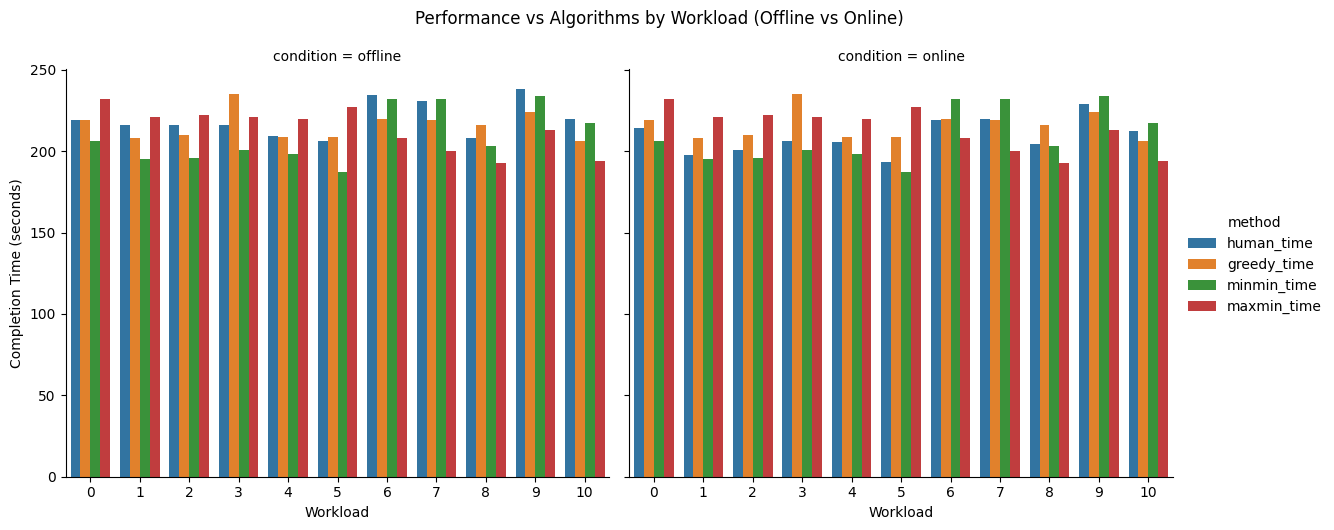

In [17]:
alg_df = heuristics_df.rename(columns={'index': 'windex'})[
    ['windex', 'greedy_time', 'minmin_time', 'maxmin_time']
]

human_df = (
    trial_df
    .groupby(['condition', 'windex'])['human_time']
    .mean()
    .reset_index()
)

alg_df = heuristics_df.rename(columns={'index': 'windex'})[
    ['windex', 'greedy_time', 'minmin_time', 'maxmin_time']
]

plot_df = human_df.merge(alg_df, on='windex', how='left')

plot_long = plot_df.melt(
    id_vars=['condition', 'windex'],
    value_vars=['human_time', 'greedy_time', 'minmin_time', 'maxmin_time'],
    var_name='method',
    value_name='time'
)

g = sns.catplot(
    data=plot_long,
    x='windex',
    y='time',
    hue='method',
    col='condition',
    kind='bar',
    height=5,
    aspect=1.2
)

g.set_axis_labels("Workload", "Completion Time (seconds)")
g.fig.suptitle("Performance vs Algorithms by Workload (Offline vs Online)", y=1.05)
plt.show()

In [18]:
trial_df_offline['condition'] = 'offline'
trial_df_online['condition']  = 'online'
trial_df = pd.concat([trial_df_offline, trial_df_online], ignore_index=True)
trial_df = trial_df[[c for c in trial_df.columns if not c.startswith('index_')]]

alg_df = heuristics_df[['index', 'greedy_time', 'minmin_time', 'maxmin_time']].copy()
alg_df = alg_df.rename(columns={'index': 'windex'})
alg_df['best_heuristic'] = alg_df[['minmin_time', 'maxmin_time', 'greedy_time']].idxmin(axis=1)
alg_df = alg_df[['windex', 'minmin_time', 'maxmin_time', 'greedy_time', 'best_heuristic']]

trial_df = trial_df.merge(alg_df, on='windex', how='left')

trial_df['best_heur_time'] = trial_df.apply(
    lambda row: row[row['best_heuristic']], axis=1
)

trial_df['gap_best'] = trial_df['human_time'] - trial_df['best_heur_time']

workload_perf = (
    trial_df
    .groupby(['windex', 'best_heuristic'])['gap_best']
    .mean()
    .reset_index()
)

category_perf = (
    workload_perf
    .groupby('best_heuristic')['gap_best']
    .agg(['mean', 'sem', 'count'])
)

print("Mean human – best-heuristic gap (seconds) by which heuristic is best:")
print(category_perf)
print()

# Test whether humans do worse when max-min is best than when min-min is best
minmin_gaps = workload_perf[workload_perf['best_heuristic'] == 'minmin_time']['gap_best']
maxmin_gaps = workload_perf[workload_perf['best_heuristic'] == 'maxmin_time']['gap_best']

tt_res = ttest_ind(maxmin_gaps, minmin_gaps, alternative='greater')

print("T-test: Are humans worse when max-min is the winning heuristic vs when min-min is?")
print(f"max-min mean gap: {maxmin_gaps.mean():.3f} sec")
print(f"min-min mean gap: {minmin_gaps.mean():.3f} sec")
print(tt_res)

Mean human – best-heuristic gap (seconds) by which heuristic is best:
                     mean       sem  count
best_heuristic                            
maxmin_time     19.945455  1.995885      5
minmin_time     11.151515  0.575805      6

T-test: Are humans worse when max-min is the winning heuristic vs when min-min is?
max-min mean gap: 19.945 sec
min-min mean gap: 11.152 sec
TtestResult(statistic=4.602269861338875, pvalue=0.0006431815625481481, df=9.0)


In [19]:
def convert_to_trial_data_with_minmax(filtered_df, heuristics_df):
    windex_cols = [c for c in filtered_df.columns if c.startswith("trial") and c.endswith("_windex")]
    SUBJ_COL = "participant_id"

    rows = []

    for _, row in filtered_df.iterrows():
        subj = row[SUBJ_COL]

        for col in windex_cols:
            m = re.match(r"trial(\d+)_windex", col)
            if m is None:
                continue
            trial_num = int(m.group(1))

            windex = row[col]
            if pd.isna(windex):
                continue
            windex = int(windex)

            human_col = f"w{windex}_completion_time"
            if human_col not in filtered_df.columns:
                continue

            human_time = row[human_col]

            rows.append({
                SUBJ_COL: subj,
                "trial": trial_num,
                "windex": windex,
                "human_time": human_time
            })

    trial_df = pd.DataFrame(rows)

    trial_df = trial_df.merge(
        heuristics_df[["index", "minmin_time", "maxmin_time"]],
        left_on="windex",
        right_on="index",
        how="left"
    )

    trial_df["dist_minmin"] = abs(trial_df["human_time"] - trial_df["minmin_time"])
    trial_df["dist_maxmin"] = abs(trial_df["human_time"] - trial_df["maxmin_time"])
    trial_df["bias_min_vs_max"] = trial_df["dist_minmin"] - trial_df["dist_maxmin"]

    return trial_df

In [20]:
trial_df_offline_mm = convert_to_trial_data_with_minmax(filtered_df_offline, heuristics_df)
trial_df_online_mm  = convert_to_trial_data_with_minmax(filtered_df_online,  heuristics_df)

subj_bias_offline = (
    trial_df_offline_mm
    .groupby("participant_id")["bias_min_vs_max"]
    .mean()
    .reset_index(name="mean_bias")
)

subj_bias_online = (
    trial_df_online_mm
    .groupby("participant_id")["bias_min_vs_max"]
    .mean()
    .reset_index(name="mean_bias")
)

In [21]:
from scipy.stats import ttest_1samp

# H: humans are closer to Min–Min than Max–Min  => mean_bias < 0
t_stat, p_val = ttest_1samp(subj_bias_offline["mean_bias"], popmean=0, alternative="less")

print("Offline Min–Min bias")
print(f"t = {t_stat:.3f}, p = {p_val:.4g}")
print(f"Mean (dist Min–Min – dist Max–Min): {subj_bias_offline['mean_bias'].mean():.2f}")

t_stat, p_val = ttest_1samp(subj_bias_online["mean_bias"], popmean=0, alternative="less")

print("\nOnline Min–Min bias")
print(f"t = {t_stat:.3f}, p = {p_val:.4g}")
print(f"Mean (dist Min–Min – dist Max–Min): {subj_bias_online['mean_bias'].mean():.2f}")

Offline Min–Min bias
t = -6.347, p = 3.695e-08
Mean (dist Min–Min – dist Max–Min): -6.42

Online Min–Min bias
t = -13.547, p = 1.716e-18
Mean (dist Min–Min – dist Max–Min): -10.77


In [22]:
def plot_minmax_offline_online(trial_df_offline_mm, trial_df_online_mm,
                               outfile="MinMaxBias_OfflineOnline.pdf"):
    subj_off = (
        trial_df_offline_mm
        .groupby("participant_id")[["dist_minmin", "dist_maxmin"]]
        .mean()
    )

    subj_on = (
        trial_df_online_mm
        .groupby("participant_id")[["dist_minmin", "dist_maxmin"]]
        .mean()
    )

    means = {
        "offline_min": subj_off["dist_minmin"].mean(),
        "offline_max": subj_off["dist_maxmin"].mean(),
        "online_min":  subj_on["dist_minmin"].mean(),
        "online_max":  subj_on["dist_maxmin"].mean(),
    }
    sems = {
        "offline_min": scipy.stats.sem(subj_off["dist_minmin"]),
        "offline_max": scipy.stats.sem(subj_off["dist_maxmin"]),
        "online_min":  scipy.stats.sem(subj_on["dist_minmin"]),
        "online_max":  scipy.stats.sem(subj_on["dist_maxmin"]),
    }

    labels = ["Min–Min", "Max–Min"]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(5, 4))
    plt.bar(x - width/2, [means["offline_min"], means["offline_max"]], width,
            yerr=[sems["offline_min"], sems["offline_max"]], label="Offline", color="#5DADE2")
    plt.bar(x + width/2, [means["online_min"], means["online_max"]], width,
            yerr=[sems["online_min"], sems["online_max"]], label="Online", color="#AED6F1")

    plt.xticks(x, labels)
    plt.ylabel("Absolute error from heuristic")
    plt.title("Closeness to Min–Min vs Max–Min")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

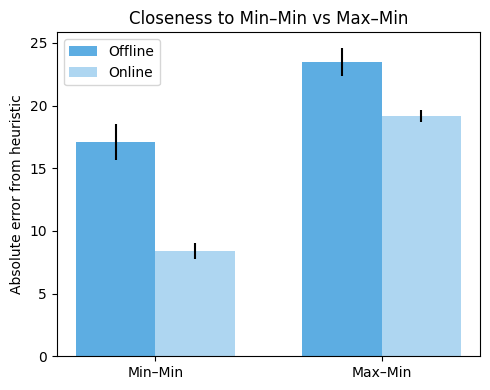

In [23]:
plot_minmax_offline_online(trial_df_offline_mm, trial_df_online_mm,
                           outfile="MinMaxBias_OfflineOnline.pdf")

In [24]:
def chef_loads_from_assignment(workload_orders, chef1_list, chef2_list):
    id_to_len = {o["id"]: (int(o["length1"]), int(o["length2"])) for o in workload_orders}

    t1 = 0
    for item in chef1_list:
        if isinstance(item, dict):
            t1 += int(item.get("length1"))
        else:
            l1, _ = id_to_len[int(item)]
            t1 += l1

    t2 = 0
    for item in chef2_list:
        if isinstance(item, dict):
            t2 += int(item.get("length2"))
        else:
            _, l2 = id_to_len[int(item)]
            t2 += l2

    return t1, t2

In [25]:
def convert_to_trial_data_with_load_bias(filtered_df, workloads_json_path, heuristics_df,
                                         human_c1_col_template="w{w}_chef1",
                                         human_c2_col_template="w{w}_chef2"):
    with open(workloads_json_path, "r", encoding="utf-8") as f:
        workloads = json.load(f)["workloads"]

    windex_cols = [c for c in filtered_df.columns if c.startswith("trial") and c.endswith("_windex")]
    SUBJ_COL = "participant_id"

    rows = []

    for _, row in filtered_df.iterrows():
        subj = row[SUBJ_COL]

        for col in windex_cols:
            m = re.match(r"trial(\d+)_windex", col)
            if m is None:
                continue
            trial_num = int(m.group(1))

            windex = row[col]
            if pd.isna(windex):
                continue
            windex = int(windex)

            workload_orders = workloads[windex]["orders"]

            c1_col = human_c1_col_template.format(w=windex)
            c2_col = human_c2_col_template.format(w=windex)
            if c1_col not in filtered_df.columns or c2_col not in filtered_df.columns:
                continue

            human_c1 = row[c1_col]
            human_c2 = row[c2_col]
            if human_c1 is None or human_c2 is None or (isinstance(human_c1, float) and np.isnan(human_c1)):
                continue

            h1, h2 = chef_loads_from_assignment(workload_orders, human_c1, human_c2)

            minmin_assign = heuristics_df.loc[windex, "minmin"]
            maxmin_assign = heuristics_df.loc[windex, "maxmin"]

            mm1, mm2 = chef_loads_from_assignment(workload_orders, minmin_assign[0], minmin_assign[1])
            mx1, mx2 = chef_loads_from_assignment(workload_orders, maxmin_assign[0], maxmin_assign[1])

            dist_min = abs(h1 - mm1) + abs(h2 - mm2)
            dist_max = abs(h1 - mx1) + abs(h2 - mx2)

            rows.append({
                SUBJ_COL: subj,
                "trial": trial_num,
                "windex": windex,
                "dist_load_minmin": dist_min,
                "dist_load_maxmin": dist_max,
                "bias_load_min_vs_max": dist_min - dist_max,
            })

    return pd.DataFrame(rows)

In [27]:
trial_df_offline_load = convert_to_trial_data_with_load_bias(
    filtered_df_offline,
    workloads_json_path="stimuli/workloads.json",
    heuristics_df=heuristics_df,
)

trial_df_online_load = convert_to_trial_data_with_load_bias(
    filtered_df_online,
    workloads_json_path="stimuli/workloads.json",
    heuristics_df=heuristics_df,
)

subj_load_off = (
    trial_df_offline_load
    .groupby("participant_id")["bias_load_min_vs_max"]
    .mean()
    .reset_index(name="mean_bias")
)

subj_load_on = (
    trial_df_online_load
    .groupby("participant_id")["bias_load_min_vs_max"]
    .mean()
    .reset_index(name="mean_bias")
)

t, p = ttest_1samp(subj_load_off["mean_bias"], popmean=0, alternative="less")
print("Offline load bias:")
print(f"t = {t:.3f}, p = {p:.4g}, mean = {subj_load_off['mean_bias'].mean():.2f}")

t, p = ttest_1samp(subj_load_on["mean_bias"], popmean=0, alternative="less")
print("\nOnline load bias:")
print(f"t = {t:.3f}, p = {p:.4g}, mean = {subj_load_on['mean_bias'].mean():.2f}")

Offline load bias:
t = -7.210, p = 1.755e-09, mean = -13.80

Online load bias:
t = -7.778, p = 2.088e-10, mean = -14.23


In [28]:
def plot_load_bias_offline_online(trial_df_offline_load, trial_df_online_load,
                                  outfile="LoadBias_OfflineOnline.pdf"):
    subj_off = (
        trial_df_offline_load
        .groupby("participant_id")[["dist_load_minmin", "dist_load_maxmin"]]
        .mean()
    )

    subj_on = (
        trial_df_online_load
        .groupby("participant_id")[["dist_load_minmin", "dist_load_maxmin"]]
        .mean()
    )

    means = {
        "offline_min": subj_off["dist_load_minmin"].mean(),
        "offline_max": subj_off["dist_load_maxmin"].mean(),
        "online_min":  subj_on["dist_load_minmin"].mean(),
        "online_max":  subj_on["dist_load_maxmin"].mean(),
    }
    sems = {
        "offline_min": scipy.stats.sem(subj_off["dist_load_minmin"]),
        "offline_max": scipy.stats.sem(subj_off["dist_load_maxmin"]),
        "online_min":  scipy.stats.sem(subj_on["dist_load_minmin"]),
        "online_max":  scipy.stats.sem(subj_on["dist_load_maxmin"]),
    }

    labels = ["Min–Min", "Max–Min"]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(5, 4))
    plt.bar(x - width/2, [means["offline_min"], means["offline_max"]], width,
            yerr=[sems["offline_min"], sems["offline_max"]], label="Offline", color="#1F618D")
    plt.bar(x + width/2, [means["online_min"], means["online_max"]], width,
            yerr=[sems["online_min"], sems["online_max"]], label="Online", color="#85C1E9")

    plt.xticks(x, labels)
    plt.ylabel("Load distance (time units)")
    plt.title("Human load allocation relative to Min–Min and Max–Min")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close()

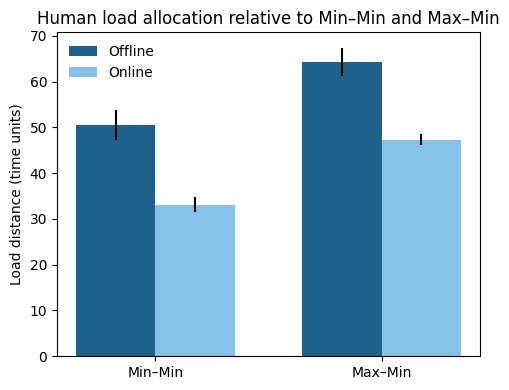

In [29]:
plot_load_bias_offline_online(trial_df_offline_load, trial_df_online_load,
                              outfile="LoadBias_OfflineOnline.pdf")

In [30]:
def normalize_assignment(assign_list):
    """
    Convert assignment list (ids or dicts) into a set of job ids (ints).
    """
    ids = []
    for item in assign_list:
        if isinstance(item, dict):
            ids.append(int(item["id"]))
        else:
            ids.append(int(item))
    return set(ids)


def jaccard_overlap(set_a, set_b):
    if len(set_a | set_b) == 0:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)


In [31]:
def convert_to_trial_data_with_overlap(filtered_df, workloads_json_path, heuristics_df,
                                       human_c1_col_template="w{w}_chef1",
                                       human_c2_col_template="w{w}_chef2"):
    with open(workloads_json_path, "r", encoding="utf-8") as f:
        workloads = json.load(f)["workloads"]

    windex_cols = [c for c in filtered_df.columns if c.startswith("trial") and c.endswith("_windex")]
    SUBJ_COL = "participant_id"

    rows = []

    for _, row in filtered_df.iterrows():
        subj = row[SUBJ_COL]

        for col in windex_cols:
            m = re.match(r"trial(\d+)_windex", col)
            if m is None:
                continue
            trial_num = int(m.group(1))

            windex = row[col]
            if pd.isna(windex):
                continue
            windex = int(windex)

            c1_col = human_c1_col_template.format(w=windex)
            c2_col = human_c2_col_template.format(w=windex)

            if c1_col not in filtered_df.columns or c2_col not in filtered_df.columns:
                continue

            human_c1 = row[c1_col]
            human_c2 = row[c2_col]
            if human_c1 is None or human_c2 is None:
                continue

            H1 = normalize_assignment(human_c1)
            H2 = normalize_assignment(human_c2)

            minmin_assign = heuristics_df.loc[windex, "minmin"]
            MM1 = normalize_assignment(minmin_assign[0])

            maxmin_assign = heuristics_df.loc[windex, "maxmin"]
            MX1 = normalize_assignment(maxmin_assign[0])

            overlap_minmin = jaccard_overlap(H1, MM1)
            overlap_maxmin = jaccard_overlap(H1, MX1)

            rows.append({
                SUBJ_COL: subj,
                "trial": trial_num,
                "windex": windex,
                "overlap_minmin": overlap_minmin,
                "overlap_maxmin": overlap_maxmin,
                "bias_overlap_min_vs_max": overlap_minmin - overlap_maxmin
            })

    return pd.DataFrame(rows)

In [29]:
trial_df_offline_ov = convert_to_trial_data_with_overlap(
    filtered_df_offline,
    workloads_json_path="workloads.json",
    heuristics_df=heuristics_df,
)

trial_df_online_ov = convert_to_trial_data_with_overlap(
    filtered_df_online,
    workloads_json_path="workloads.json",
    heuristics_df=heuristics_df,
)

subj_ov_off = (
    trial_df_offline_ov
    .groupby("participant_id")["bias_overlap_min_vs_max"]
    .mean()
    .reset_index(name="mean_bias")
)

subj_ov_on = (
    trial_df_online_ov
    .groupby("participant_id")["bias_overlap_min_vs_max"]
    .mean()
    .reset_index(name="mean_bias")
)

t, p = ttest_1samp(subj_ov_off["mean_bias"], popmean=0, alternative="greater")
print("Offline overlap bias:")
print(f"t = {t:.3f}, p = {p:.4g}, mean = {subj_ov_off['mean_bias'].mean():.3f}")

t, p = ttest_1samp(subj_ov_on["mean_bias"], popmean=0, alternative="greater")
print("\nOnline overlap bias:")
print(f"t = {t:.3f}, p = {p:.4g}, mean = {subj_ov_on['mean_bias'].mean():.3f}")

Offline overlap bias:
t = 14.799, p = 8.178e-20, mean = 0.158

Online overlap bias:
t = 9.787, p = 2.049e-13, mean = 0.133
